<a href="https://colab.research.google.com/github/Medese/Evaluation-metrics/blob/main/Test_123.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "advertising.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ashydv/advertising-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/tmp/ipykernel_5719/1963029285.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'advertising-dataset' dataset.


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


**Load Data**

In [7]:
X = df[["TV", "Radio", "Newspaper"]].values
y = df["Sales"].values.reshape(-1, 1)

**Train/test Split**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Scale features and Target**

In [9]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

**Convert to tensors**

In [10]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)


**Define the model**

In [11]:
class SalesRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)

model = SalesRegressor(input_dim=X_train.shape[1])


**Loss and optimizer**

In [12]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


**Training loop**

In [13]:
epochs = 500
train_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [50/500], Loss: 0.0572
Epoch [100/500], Loss: 0.0376
Epoch [150/500], Loss: 0.0260
Epoch [200/500], Loss: 0.0191
Epoch [250/500], Loss: 0.0145
Epoch [300/500], Loss: 0.0100
Epoch [350/500], Loss: 0.0072
Epoch [400/500], Loss: 0.0083
Epoch [450/500], Loss: 0.0053
Epoch [500/500], Loss: 0.0035


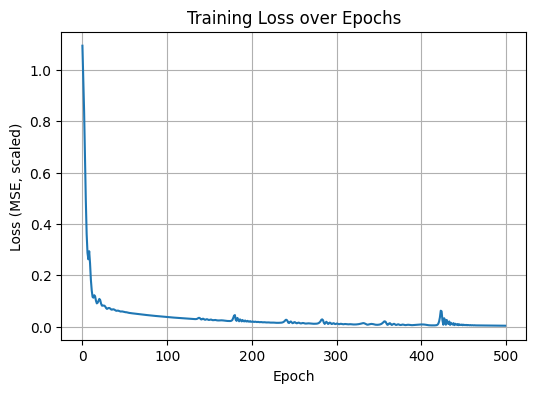

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE, scaled)")
plt.grid(True)
plt.show()

**Evaluation test set**

In [15]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_t).numpy()

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test_scaled)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("\n--- Test Set Performance ---")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")


--- Test Set Performance ---
MSE  : 4.2318
RMSE : 2.0571
R2   : 0.8631


**Prediction test on a new/custom sample**

In [16]:
sample = np.array([[150.0, 25.0, 20.0]])   # TV, Radio, Newspaper
sample_scaled = x_scaler.transform(sample)
sample_tensor = torch.tensor(sample_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    pred_scaled = model(sample_tensor).numpy()

pred_sales = y_scaler.inverse_transform(pred_scaled)

print("\n--- Prediction Test ---")
print(f"Input -> TV: {sample[0][0]}, Radio: {sample[0][1]}, Newspaper: {sample[0][2]}")
print(f"Predicted Sales: {pred_sales[0][0]:.2f}")


--- Prediction Test ---
Input -> TV: 150.0, Radio: 25.0, Newspaper: 20.0
Predicted Sales: 14.56


**Comparison**

In [20]:
comparison = pd.DataFrame({"Actual":y_true.flatten(), "predicted": y_pred.flatten()})
comparison ["Error"] = comparison["Actual"] - comparison["predicted"]
comparison.head(10)

,Actual,predicted,Error
0,16.9,17.420982,-0.520982
1,22.4,22.992582,-0.592582
2,21.4,21.032959,0.367041
3,7.3,6.085440,1.214560
4,24.7,24.842871,-0.142871
5,12.6,13.769645,-1.169645
6,22.3,22.756731,-0.456731
7,8.4,9.936931,-1.536931
8,16.5,17.298038,-0.798038
9,16.1,16.954918,-0.854918
